In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import py21cmfast as p21c

from py21cmemu import Emulator

from py21cmemu.properties import emulator_properties
import tools21cm
import h5py

In [3]:
p21c.__version__

'3.4.0'

In [12]:
props = emulator_properties()
props.user_params['HII_DIM'] = 256
props.user_params['DIM'] = 768
props.user_params['N_THREADS'] = 60
limits = props.limits

In [13]:
# Let's take a test param that is already in 21cmFAST-friendly units
test_param = [-0.98454527, 0.84028646, -1.01608287, 0.03414988, 9.02499104, 0.45168016, 40.0, 500.0, 1.0]
keys = ['F_STAR10', 'ALPHA_STAR', 'F_ESC10', 'ALPHA_ESC', 'M_TURN', 't_STAR', 'L_X','NU_X_THRESH', 'X_RAY_SPEC_INDEX']

input_dict = {k:v for k, v in zip(keys, test_param)}

In [14]:
ap = p21c.AstroParams(input_dict)

In [15]:
print(props.user_params)

{'BOX_LEN': 250, 'DIM': 768, 'HII_DIM': 256, 'USE_FFTW_WISDOM': True, 'HMF': 1, 'USE_RELATIVE_VELOCITIES': False, 'POWER_SPECTRUM': 0, 'N_THREADS': 60, 'PERTURB_ON_HIGH_RES': False, 'NO_RNG': False, 'USE_INTERPOLATION_TABLES': True, 'FAST_FCOLL_TABLES': False, 'USE_2LPT': True, 'MINIMIZE_MEMORY': False}


In [16]:
emu_redshifts = [ 5.90059,   6.038602,  6.179374  ,6.322961  ,6.46942   ,6.618808 , 6.771184,
  6.926608  ,7.08514   ,7.246843,  7.411779  ,7.580015  ,7.751615  ,7.926647,
  8.10518   ,8.287283  ,8.473028,  8.662489  ,8.855739  ,9.052854  ,9.25391,
  9.458988  ,9.668168  ,9.881531, 10.09916  ,10.32114  ,10.54757  ,10.77852,
 11.01409  ,11.25437  ,11.49946, 11.74944  ,12.00443  ,12.26452  ,12.52981,
 12.80041  ,13.07641  ,13.35794,  13.6451   ,13.938    ,14.23676  ,14.5415,
 14.85233  ,15.16937  ,15.49276 , 15.82262  ,16.15907  ,16.50225  ,16.85229,
 17.20934  ,17.57353  ,17.945   , 18.3239   ,18.71038  ,19.10458  ,19.50668,
 19.91681  ,20.33514  ,20.76185  ,21.19708  ,21.64102  ,22.09384  ,22.55572,
 23.02683  ,23.50737  ,23.99751  ,24.49747  ,25.00741  ,25.52756  ,26.05811,
 26.59927  ,27.15126  ,27.71428  ,28.28857  ,28.87434  ,29.47183  ,30.08126,
 30.70289  ,31.33694  ,31.98368  ,32.64336  ,33.31622  ,34.00255  ,34.7026  ]
coeval = p21c.run_coeval(redshift = emu_redshifts,
                user_params = props.user_params,
                astro_params = ap,
                flag_options = props.flag_options,
                cosmo_params = props.cosmo_params,
                direc = '_cache'
                )

In [ ]:
# k-values: 0.03820577, 0.05725007, 0.07778031, 0.101638,   0.1347107,  0.1815186,
# 0.2444601,  0.3299734,  0.4460977,  0.6021986,  0.8131821,  1.097917
power_spectrum21cmfast = []
real_k_values = np.array([0.03720577, 0.03920577, 0.07529437, 0.08026625000000001, 0.12300975, 0.14641164999999998, 0.21662555000000003, 0.27229464999999997, 
0.38765215, 0.50454325, 0.6998539500000001, 0.92651025, 1.26932375, 1.54078924, 2.1156804])
k_values = []
for box in coeval:
    PS, k = tools21cm.power_spectrum.power_spectrum_1d(box.brightness_temp, box_dims= coeval[0].user_params.BOX_LEN, kbins=real_k_values)
    power_spectrum21cmfast.add(PS)

power_spectrum21cmfast = np.array(power_spectrum21cmfast)
k_values = k

power_spectrum_21cmfast = power_spectrum21cmfast * (k_values)**3 / (2 * np.pi**2)

[0.03820577 0.05725007 0.07778031 0.101638   0.1347107  0.1815186
 0.2444601  0.3299734  0.4460977  0.6021986  0.8131821  1.097917
 1.4050565  1.82823482]


In [23]:
emu = Emulator()

2026-05-11 15:27:27.691123: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-11 15:27:44.613010: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-11 15:27:44.613089: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-11 15:27:44.640433: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-11 15:27:51.664539: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: A

In [24]:
theta, out, errs = emu.predict(input_dict)

In [25]:
zs = out.redshifts
xHI = out.xHI
Tb = out.Tb
k = out.PS_ks

In [120]:
power_spectrum21cmfast = np.array(power_spectrum21cmfast)
power_spectrum_21cmfast = power_spectrum21cmfast * (k_values)**3 / (2 * np.pi**2)

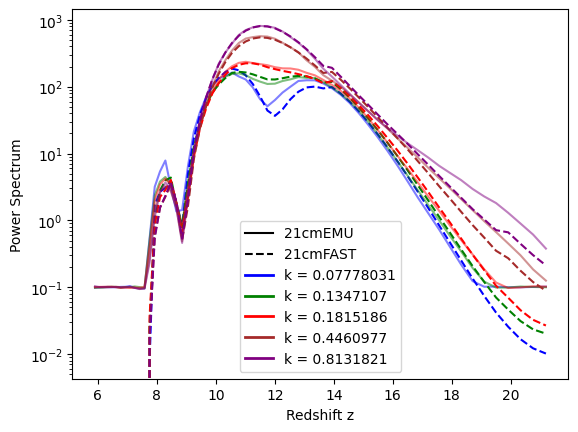

In [141]:
from matplotlib.lines import Line2D

k_index = [2, 4, 5, 8, 10]
cs = ['blue', 'green', 'red','brown','purple']
custom_legend = [
    Line2D([0], [0], color='black', linestyle='-', label='21cmEMU'),
    Line2D([0], [0], color='black', linestyle='--', label='21cmFAST')
]

for i, color in zip(k_index, cs):
    plt.plot(out.PS_redshifts, out.PS[:,i], alpha = 0.5, color = color)
    plt.plot(out.PS_redshifts, power_spectrum_21cmfast[:-24, i], linestyle = '--', color = color)
    custom_legend.append(
        Line2D([0], [0], color=color, linestyle='-', linewidth=2, label=f'k = {k_values[i]}')
    )
plt.yscale('log')
plt.ylabel('Power Spectrum')
plt.xlabel('Redshift z')
plt.legend(handles=custom_legend)
plt.show()

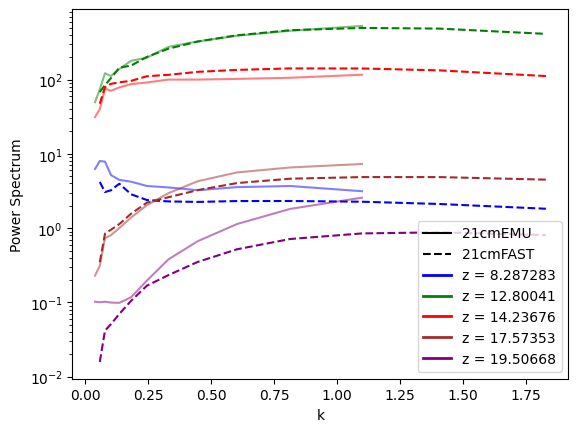

In [ ]:
z_index = [16, 20, 37, 44, 60, ]
cs = ['blue', 'green', 'red','brown','purple']

custom_legend = [
    Line2D([0], [0], color='black', linestyle='-', label='21cmEMU'),
    Line2D([0], [0], color='black', linestyle='--', label='21cmFAST')
]

for i, color  in zip(z_index, cs):

    plt.plot(k, out.PS[i, :], color = color, alpha = 0.5)
    plt.plot(k_values, power_spectrum_21cmfast[i], linestyle = '--', color = color)

    custom_legend.append(
        Line2D([0], [0], color=color, linestyle='-', linewidth=2, label=f'z = {out.PS_redshifts[i]}')
    )

plt.yscale('log')
plt.xlabel('k')
plt.ylabel('Power Spectrum')
plt.legend(handles=custom_legend)
plt.show()

In [144]:
from sklearn.metrics import r2_score

In [160]:
print(np.shape(out.PS[15:]))
print(np.shape(power_spectrum_21cmfast[15:-24, :-2]))

(45, 12)
(45, 12)


In [158]:
r2_score(np.nan_to_num(power_spectrum_21cmfast[15:-24, :-2]), out.PS[15:])

0.8997400617114066

In [146]:
print(out.PS[0])

[0.09724363 0.09450088 0.09829386 0.09920314 0.09829982 0.10035819
 0.10158679 0.10058776 0.10035238 0.10134596 0.10375259 0.10263386]


In [152]:
print(power_spectrum_21cmfast[0:12])

[[nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [nan  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]


In [153]:
print(power_spectrum_21cmfast[12:15])

[[       nan 0.00319515 0.00763756 0.0142775  0.02586918 0.03613447
  0.03643703 0.02606101 0.02201032 0.01905361 0.0170694  0.01555107
  0.01333296 0.01164656]
 [       nan 1.2661865  1.68062933 1.03857379 0.9365234  0.86849211
  0.70879065 0.65983034 0.58912967 0.57438562 0.54281886 0.52189106
  0.4838738  0.41279211]
 [       nan 2.96675071 2.68369402 2.59856321 2.80296234 2.23711982
  1.65045135 1.57735931 1.5558344  1.5414453  1.54868328 1.4634743
  1.35248921 1.17393298]]


In [156]:
print(power_spectrum_21cmfast[20:40])

[[         nan  15.27185634  16.76519406  13.92997093  12.17881936
    9.02406001   7.67085365   7.54529914   8.23604897   9.54138768
   10.50884679  11.08672594  10.68462237   9.15532723]
 [         nan  30.07696666  37.87708004  32.64727737  28.79953476
   23.44933618  21.01220864  21.44370823  23.92939756  28.02852292
   30.92358677  32.74180219  31.58145215  27.15311743]
 [         nan  49.3102744   67.02943733  59.81266972  52.73712903
   47.06407283  43.46199664  45.9484211   52.40196692  61.90675642
   68.94189773  73.33064524  70.79282119  60.93211829]
 [         nan  70.5672632  103.24267043  93.29338043  82.19461519
   79.1424055   75.55333143  83.34129299  96.87082292 115.03902055
  129.65525457 138.45150745 133.88406848 115.31455952]
 [         nan  86.52280458 134.82226448 121.60673752 107.86560297
  112.86688193 114.74142304 131.63343149 156.54009432 188.595075
  215.08415557 231.37668399 224.3665092  193.23542937]
 [         nan  99.09141229 165.31742388 149.4799513  134